In [1]:
import os
import sys
sys.path.append('tools/model_tools')
sys.path.append('tools/plot_tools')
import copy
import logging
import numpy as np
import matplotlib
import pygmt
import math
import shutil
import warnings
import pandas as pd
import tempfile
import matplotlib.pyplot as plt
import scipy
import h5py
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib as mpl
from scipy import io
from matplotlib.ticker import AutoMinorLocator
from scipy import interpolate, signal
from matplotlib.path import Path
from tools import make_tri_mesh, make_triangular_patch_stuff, load_mcmc_results, get_boundary_curves, get_boundary_indices, llh2local, local2llh, distancept
from tools import _box_from_anchor, get_default_meca_details, add_meca_legend_fixed_deg
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.path import Path
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.collections import LineCollection
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.ticker import FormatStrFormatter
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from matplotlib import colors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import ticker
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MultipleLocator
from scipy.stats import norm
from pathlib import Path
from scipy.interpolate import interp1d
from scipy.stats import gaussian_kde


# Setup logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Suppress NaN warnings in segment lists
warnings.filterwarnings("ignore", message=".*contains NaNs.*")

Loaded contour data with shape: (2904, 3)
Converted contour data to local Cartesian coordinates with shape: (2904, 2)
Shape of contrkm (local coords): (2904, 3)


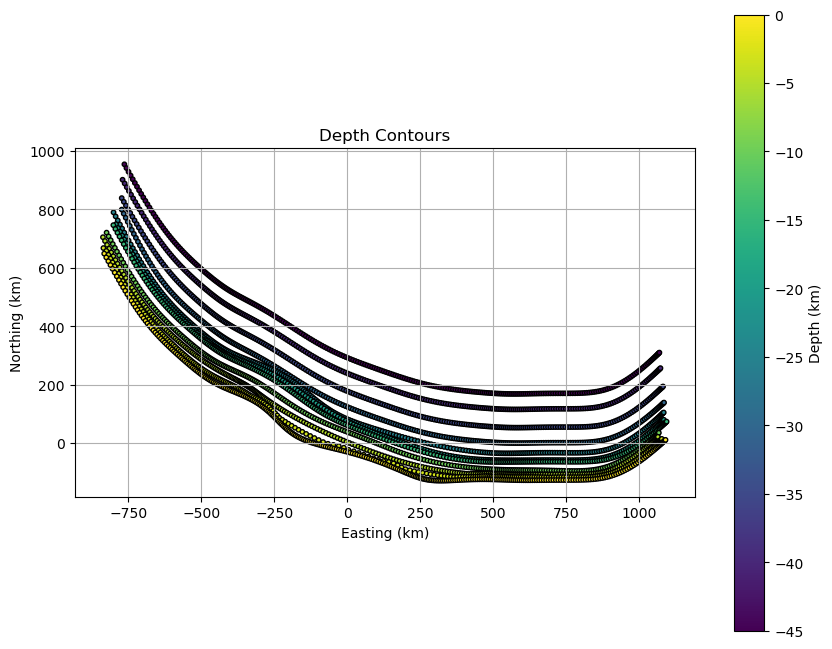

Initial nodet0 shape: (294, 3)
Initial nodeb0 shape: (263, 3)
After edge removal - nodet0 shape: (292, 3)
After edge removal - nodeb0 shape: (261, 3)
Resampled nodet shape: (187, 3)
Resampled nodeb shape: (179, 3)
nd0 shape: (4946, 3)
el shape: (9474, 3)
Generated triangular mesh with elements shape: (9474, 3)
Generated triangular mesh with nodes shape: (4946, 3)


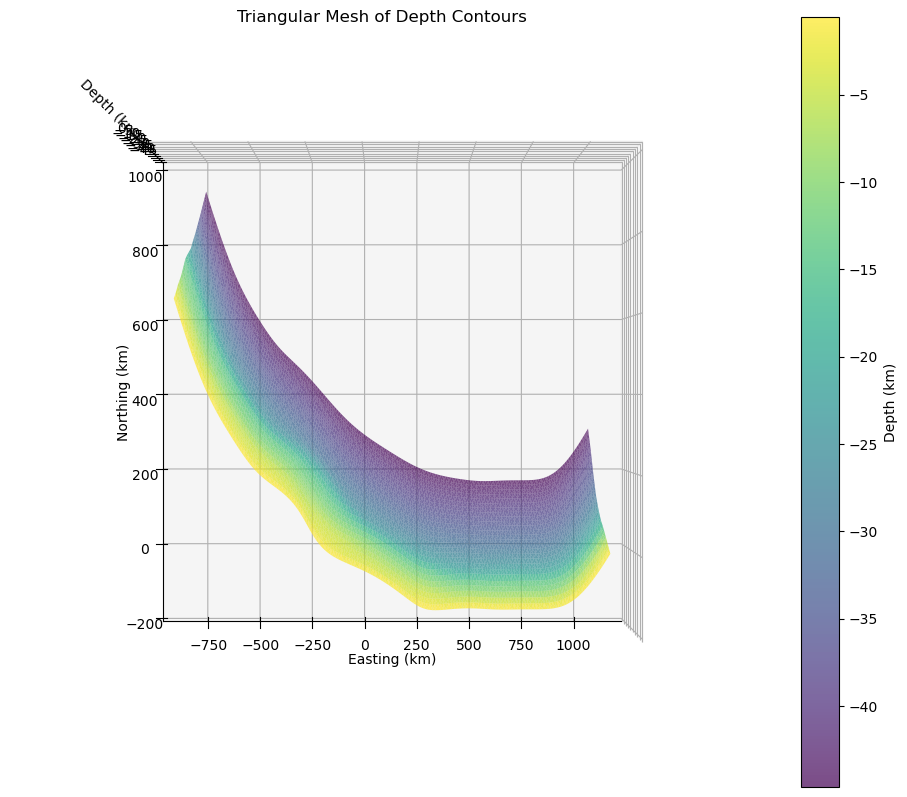

In [2]:
# Choose the folder for elastic or viscoelastic data
folder_choice = 2  # 1 for elastic, 2 for viscoelastic

# Assign base_path based on folder_choice
if folder_choice == 1:
    base_path = 'data/himalaya_elastic/'
else:
    base_path = 'data/himalaya_viscoelastic/'

# Load contour data
contr_path = 'slab_inputs/Himalaya'

# Check if the contour file exists
if folder_choice == 1:
    contr_file = f"{contr_path}/him_contours_elastic.txt"
    contr = np.loadtxt(contr_file, delimiter=',')

    # Convert to DataFrame for easier sorting
    contr_df = pd.DataFrame(contr, columns=['lon', 'lat', 'depth'])

    # Sort in descending order based on depth
    contr_df_sorted = contr_df.sort_values(by='depth', ascending=False)

    # Convert back to NumPy array
    contr = contr_df_sorted.to_numpy()


elif folder_choice == 2:
    contr_file = f"{contr_path}/him_contours_visco.txt"
    contr = np.loadtxt(contr_file, delimiter=',')
print("Loaded contour data with shape:", contr.shape)


# Define origin and interval for contour lines
origin = [83, 28]
intv = 12 # Interval for contour lines

# Convert to local Cartesian coordinates
contrkm_xy = llh2local(contr, origin)
print("Converted contour data to local Cartesian coordinates with shape:", contrkm_xy.shape)

# Append the original 3rd column (depth) as the Z component
contrkm = np.hstack((contrkm_xy, contr[:, 2].reshape(-1, 1)))
print("Shape of contrkm (local coords):", contrkm.shape)

# # Sort contrkm by depth (3rd column, index 2) in descending order
# contrkm_sorted = contrkm[contrkm[:, 2].argsort()[::-1]]

# Sort by depth (3rd column, index 2) in ascending order
contrkm_sorted = contrkm[np.lexsort((contrkm[:, 0], -contrkm[:, 2]))]

# contrkm_sorted = contrkm[np.argsort(-contrkm[:, 2])]

# Plot depth contours
plt.figure(figsize=(10, 8))
scatter = plt.scatter(contrkm[:, 0], contrkm[:, 1], c=contrkm[:, 2],
                      cmap='viridis', s=10, edgecolor='k')
plt.colorbar(scatter, label='Depth (km)')
plt.xlabel('Easting (km)')
plt.ylabel('Northing (km)')
plt.title('Depth Contours')
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True)
plt.show()

# Generate triangular mesh
el, nd = make_tri_mesh(contrkm_sorted, intv)

print("Generated triangular mesh with elements shape:", el.shape)
print("Generated triangular mesh with nodes shape:", nd.shape)

# 3D plot as before
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
trisurf = ax.plot_trisurf(nd[:, 0], nd[:, 1], nd[:, 2],
                          triangles=el, cmap='viridis',
                          edgecolor='none', alpha=0.7)
fig.colorbar(trisurf, ax=ax, label='Depth (km)')
ax.set_xlabel('Easting (km)')
ax.set_ylabel('Northing (km)')
ax.set_zlabel('Depth (km)')
ax.set_title('Triangular Mesh of Depth Contours')
ax.view_init(elev=90, azim=-90)
plt.show()

# Compute patch properties
patch_stuff = make_triangular_patch_stuff(el, nd)
centers = patch_stuff['centroids_faces']
strikevecs_small = patch_stuff['strikevec_faces']
dipvecs_small = patch_stuff['dipvec_faces']
dip_angle = patch_stuff['dip_faces']

centroids = copy.deepcopy(patch_stuff['centroids_faces'])
strikes = copy.deepcopy(patch_stuff['strikevec_faces'])
dipvecs = copy.deepcopy(patch_stuff['dipvec_faces'])
dipangle = copy.deepcopy(patch_stuff['dip_faces'])


In [14]:
# # set up data directory
# load the centroid data
basic_data_path = os.path.join('basic_data')

# ---------------------------------------------------------------------------
#  2.  CENTROID LOCATIONS (lon, lat, depth)
# ---------------------------------------------------------------------------
centers_llh_df = pd.read_csv(f"{basic_data_path}/centroids_llh.txt",
                             sep=r"\s+", header=None,
                             names=['lon', 'lat', 'depth'])

# Convert to numeric and drop NaN values
centers_llh_df[['lon', 'lat']] = centers_llh_df[['lon', 'lat']].apply(
    pd.to_numeric, errors='coerce')
centers_llh_df = centers_llh_df.dropna().reset_index(drop=True)

centers_llh_df.shape

(9474, 3)

In [4]:
# ---------------------------------------------------------------------
# Input and output directories
# ---------------------------------------------------------------------
elastic_dir = "Elastic_results"
visco_dir = "Visco_results"

elastic_mean_dir = "Elastic_mean_results"
visco_mean_dir = "Visco_mean_results"

# Number of initial MCMC samples to discard
discard = 900


# ---------------------------------------------------------------------
# Files for which the mean will be calculated
# ---------------------------------------------------------------------
mean_files = [
    "M_locked_depths_U.txt",
    "M_locked_depths_L.txt",
    "M_ring_tau.txt",
    "dhat.txt",
    "locked_index.txt",
    "creep_rates.txt",
]


# ---------------------------------------------------------------------
# Files that are already mean quantities and should only be copied
# ---------------------------------------------------------------------
copy_files = [
    "mean_ring_tau.txt",
]


# ---------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------
def _ensure_dir(path):
    """Create a directory if it does not already exist."""
    os.makedirs(path, exist_ok=True)


def _list_subfolders(parent_directory):
    """Return all immediate non-hidden subfolders."""
    if not os.path.isdir(parent_directory):
        raise FileNotFoundError(
            f"Input directory not found: {parent_directory}"
        )

    return sorted(
        folder_name
        for folder_name in os.listdir(parent_directory)
        if (
            os.path.isdir(
                os.path.join(parent_directory, folder_name)
            )
            and not folder_name.startswith(".")
        )
    )


def _infer_expected_columns(file_path, probe_rows=100):
    """
    Determine the expected number of columns from the most common
    column count among the first probe_rows non-empty rows.

    This prevents one malformed row from defining the expected shape.
    """
    column_frequencies = {}
    rows_checked = 0

    with open(file_path, "r") as file_handle:
        for line in file_handle:

            # Remove comments and surrounding whitespace
            stripped_line = line.split("#", 1)[0].strip()

            if not stripped_line:
                continue

            number_of_columns = len(stripped_line.split())

            column_frequencies[number_of_columns] = (
                column_frequencies.get(number_of_columns, 0) + 1
            )

            rows_checked += 1

            if rows_checked >= probe_rows:
                break

    if not column_frequencies:
        raise ValueError(
            f"Numeric file is empty: {file_path}"
        )

    expected_columns = max(
        column_frequencies,
        key=column_frequencies.get,
    )

    return expected_columns


def _calculate_mean_from_file_after_discard(
    file_path,
    discard_samples,
):
    """
    Calculate the column-wise mean directly from a text file.

    The first discard_samples rows are treated as burn-in and removed.

    After burn-in:
        - rows with the correct number of numerical values are used;
        - rows with missing or extra columns are skipped;
        - rows containing nonnumeric values are skipped;
        - NaN values are ignored column by column.

    The complete file is not rejected because of one malformed row.
    """
    if discard_samples < 0:
        raise ValueError(
            f"discard must be non-negative, "
            f"received {discard_samples}"
        )

    expected_columns = _infer_expected_columns(
        file_path
    )

    # Running statistics avoid loading the complete large file
    # into memory.
    column_sum = np.zeros(
        expected_columns,
        dtype=np.float64,
    )

    column_count = np.zeros(
        expected_columns,
        dtype=np.int64,
    )

    total_rows = 0
    retained_rows = 0
    used_rows = 0
    skipped_rows = 0

    with open(file_path, "r") as file_handle:
        for line_number, line in enumerate(
            file_handle,
            start=1,
        ):

            # Remove comments and surrounding whitespace
            stripped_line = line.split("#", 1)[0].strip()

            if not stripped_line:
                continue

            # Count every non-empty numerical-data line as one
            # MCMC sample.
            total_rows += 1

            # Discard the first MCMC burn-in rows.
            if total_rows <= discard_samples:
                continue

            retained_rows += 1

            tokens = stripped_line.split()
            actual_columns = len(tokens)

            # Skip rows with missing or additional columns.
            if actual_columns != expected_columns:
                skipped_rows += 1

                if skipped_rows <= 10:
                    logging.warning(
                        f"Skipping malformed row: "
                        f"file={file_path}, "
                        f"line={line_number}, "
                        f"expected_columns={expected_columns}, "
                        f"found_columns={actual_columns}"
                    )

                elif skipped_rows == 11:
                    logging.warning(
                        f"Additional malformed rows in "
                        f"{file_path} will be skipped without "
                        f"individual warning messages."
                    )

                continue

            # Convert the row to numerical values.
            try:
                row = np.asarray(
                    tokens,
                    dtype=np.float64,
                )

            except ValueError as error:
                skipped_rows += 1

                if skipped_rows <= 10:
                    logging.warning(
                        f"Skipping nonnumeric row: "
                        f"file={file_path}, "
                        f"line={line_number}, "
                        f"error={error}"
                    )

                elif skipped_rows == 11:
                    logging.warning(
                        f"Additional malformed rows in "
                        f"{file_path} will be skipped without "
                        f"individual warning messages."
                    )

                continue

            # Reproduce np.nanmean behavior by ignoring NaN values
            # separately in every column.
            valid_values = ~np.isnan(row)

            column_sum[valid_values] += row[valid_values]
            column_count[valid_values] += 1

            used_rows += 1

    if total_rows <= discard_samples:
        raise ValueError(
            f"Not enough rows in {file_path}: "
            f"total_rows={total_rows}, "
            f"discard={discard_samples}"
        )

    if used_rows == 0:
        raise ValueError(
            f"No valid rows remain in {file_path} after "
            f"discarding {discard_samples} rows"
        )

    # Initialize columns without valid samples as NaN.
    mean_vector = np.full(
        expected_columns,
        np.nan,
        dtype=np.float64,
    )

    # Mean = column sum / number of valid values in each column.
    np.divide(
        column_sum,
        column_count,
        out=mean_vector,
        where=column_count > 0,
    )

    # Save as number_of_parameters x 1.
    mean_column = mean_vector.reshape(-1, 1)

    return (
        mean_column,
        total_rows,
        expected_columns,
        retained_rows,
        used_rows,
        skipped_rows,
    )


# ---------------------------------------------------------------------
# Process one individual source folder
# ---------------------------------------------------------------------
def process_individual_folder(
    source_folder,
    destination_folder,
    discard_samples,
):
    """
    Calculate mean files for one individual folder and save them
    inside the corresponding destination folder.
    """
    _ensure_dir(destination_folder)

    folder_name = os.path.basename(
        source_folder
    )

    # -------------------------------------------------------------
    # Calculate and save mean files
    # -------------------------------------------------------------
    for filename in mean_files:
        source_file = os.path.join(
            source_folder,
            filename,
        )

        if not os.path.isfile(source_file):
            logging.warning(
                f"File not found: {source_file}"
            )
            continue

        try:
            (
                mean_column,
                total_rows,
                expected_columns,
                retained_rows,
                used_rows,
                skipped_rows,
            ) = _calculate_mean_from_file_after_discard(
                file_path=source_file,
                discard_samples=discard_samples,
            )

            mean_filename = f"mean_{filename}"

            destination_file = os.path.join(
                destination_folder,
                mean_filename,
            )

            np.savetxt(
                destination_file,
                mean_column,
                fmt="%.8e",
            )

            print(
                f"[MEAN SAVED] "
                f"folder={folder_name}, "
                f"source_file={filename}, "
                f"output_file={mean_filename}, "
                f"total_rows={total_rows}, "
                f"expected_columns={expected_columns}, "
                f"after_discard_rows={retained_rows}, "
                f"used_rows={used_rows}, "
                f"skipped_bad_rows={skipped_rows}, "
                f"saved_shape={mean_column.shape}"
            )

        except Exception as error:
            logging.error(
                f"Failed to process {source_file}: {error}"
            )

    # -------------------------------------------------------------
    # Copy files that are already mean quantities
    # -------------------------------------------------------------
    for filename in copy_files:
        source_file = os.path.join(
            source_folder,
            filename,
        )

        if not os.path.isfile(source_file):
            logging.warning(
                f"File not found: {source_file}"
            )
            continue

        try:
            destination_file = os.path.join(
                destination_folder,
                filename,
            )

            shutil.copy2(
                source_file,
                destination_file,
            )

            print(
                f"[COPIED] "
                f"folder={folder_name}, "
                f"file={filename}"
            )

        except Exception as error:
            logging.error(
                f"Failed to copy {source_file}: {error}"
            )


# ---------------------------------------------------------------------
# Process every individual subfolder in a result directory
# ---------------------------------------------------------------------
def process_result_directory(
    source_root,
    destination_root,
    discard_samples,
):
    """
    Mirror every source subfolder inside the destination directory
    and calculate its mean files independently.
    """
    _ensure_dir(destination_root)

    source_subfolders = _list_subfolders(
        source_root
    )

    if not source_subfolders:
        logging.warning(
            f"No subfolders found inside: {source_root}"
        )
        return

    for folder_name in source_subfolders:
        source_folder = os.path.join(
            source_root,
            folder_name,
        )

        destination_folder = os.path.join(
            destination_root,
            folder_name,
        )

        print(
            f"\nProcessing folder: {source_folder}"
        )

        process_individual_folder(
            source_folder=source_folder,
            destination_folder=destination_folder,
            discard_samples=discard_samples,
        )


# ---------------------------------------------------------------------
# Process Elastic_results
# ---------------------------------------------------------------------
process_result_directory(
    source_root=elastic_dir,
    destination_root=elastic_mean_dir,
    discard_samples=discard,
)


# ---------------------------------------------------------------------
# Process Visco_results
# ---------------------------------------------------------------------
process_result_directory(
    source_root=visco_dir,
    destination_root=visco_mean_dir,
    discard_samples=discard,
)


Processing folder: Elastic_results/Bline_Block_I
[MEAN SAVED] folder=Bline_Block_I, source_file=M_locked_depths_U.txt, output_file=mean_M_locked_depths_U.txt, total_rows=16666, expected_columns=20, after_discard_rows=15766, used_rows=15766, skipped_bad_rows=0, saved_shape=(20, 1)
[MEAN SAVED] folder=Bline_Block_I, source_file=M_locked_depths_L.txt, output_file=mean_M_locked_depths_L.txt, total_rows=16666, expected_columns=20, after_discard_rows=15766, used_rows=15766, skipped_bad_rows=0, saved_shape=(20, 1)
[MEAN SAVED] folder=Bline_Block_I, source_file=M_ring_tau.txt, output_file=mean_M_ring_tau.txt, total_rows=16666, expected_columns=20, after_discard_rows=15766, used_rows=15766, skipped_bad_rows=0, saved_shape=(20, 1)
[MEAN SAVED] folder=Bline_Block_I, source_file=dhat.txt, output_file=mean_dhat.txt, total_rows=16666, expected_columns=583, after_discard_rows=15766, used_rows=15766, skipped_bad_rows=0, saved_shape=(583, 1)
[MEAN SAVED] folder=Bline_Block_I, source_file=locked_index.

2026-08-17 14:38:33,586 - WARNING - Skipping malformed row: file=Visco_results/visco_block_I_100_1000eta/locked_index.txt, line=14007, expected_columns=9474, found_columns=7884


[MEAN SAVED] folder=visco_block_I_100_1000eta, source_file=locked_index.txt, output_file=mean_locked_index.txt, total_rows=14006, expected_columns=9474, after_discard_rows=13106, used_rows=13105, skipped_bad_rows=1, saved_shape=(9474, 1)


2026-08-17 14:38:41,642 - WARNING - Skipping malformed row: file=Visco_results/visco_block_I_100_1000eta/creep_rates.txt, line=8934, expected_columns=9474, found_columns=29


[MEAN SAVED] folder=visco_block_I_100_1000eta, source_file=creep_rates.txt, output_file=mean_creep_rates.txt, total_rows=8933, expected_columns=9474, after_discard_rows=8033, used_rows=8032, skipped_bad_rows=1, saved_shape=(9474, 1)
[COPIED] folder=visco_block_I_100_1000eta, file=mean_ring_tau.txt

Processing folder: Visco_results/visco_block_I_100eta
[MEAN SAVED] folder=visco_block_I_100eta, source_file=M_locked_depths_U.txt, output_file=mean_M_locked_depths_U.txt, total_rows=14173, expected_columns=20, after_discard_rows=13273, used_rows=13273, skipped_bad_rows=0, saved_shape=(20, 1)
[MEAN SAVED] folder=visco_block_I_100eta, source_file=M_locked_depths_L.txt, output_file=mean_M_locked_depths_L.txt, total_rows=14173, expected_columns=20, after_discard_rows=13273, used_rows=13273, skipped_bad_rows=0, saved_shape=(20, 1)
[MEAN SAVED] folder=visco_block_I_100eta, source_file=M_ring_tau.txt, output_file=mean_M_ring_tau.txt, total_rows=14173, expected_columns=20, after_discard_rows=13273, 

In [12]:
observed_baseline_path = 'basic_data/observed_baseline'

# ── LOAD OBSERVED BASELINE DATA ───────────────────────────────────────────────
baseends_df = pd.read_csv(f"{observed_baseline_path}/baseends.txt", sep=r'\s+', header=None)
baseends_df = baseends_df.apply(pd.to_numeric, errors="coerce")

vbase_df = pd.read_csv(f"{observed_baseline_path}/vbase.txt", sep=r'\s+', header=None)
vbase_df = vbase_df.apply(pd.to_numeric, errors="coerce")

l_df = pd.read_csv(f"{observed_baseline_path}/l.txt", sep=r'\s+', header=None)
l_df = l_df.apply(pd.to_numeric, errors="coerce")

print(baseends_df.shape)

(583, 4)


In [13]:
# ---------------------------------------------------------------------
# Combine baseends coordinates with every mean_dhat.txt file
#
# Output column order:
#   longitude_station_1
#   latitude_station_1
#   longitude_station_2
#   latitude_station_2
#   mean_dhat
#
# Each existing mean_dhat.txt is overwritten as a 583 x 5 text file.
# ---------------------------------------------------------------------

mean_result_roots = [
    "Elastic_mean_results",
    "Visco_mean_results",
]


# ---------------------------------------------------------------------
# Validate the baseline endpoint coordinates
# ---------------------------------------------------------------------
if baseends_df.shape[1] != 4:
    raise ValueError(
        f"baseends.txt must contain exactly 4 columns, "
        f"but found shape {baseends_df.shape}"
    )

baseends_values = baseends_df.to_numpy(dtype=float)

if np.isnan(baseends_values).any():
    bad_rows = np.where(
        np.isnan(baseends_values).any(axis=1)
    )[0]

    raise ValueError(
        f"baseends.txt contains nonnumeric or missing values "
        f"at row indices: {bad_rows.tolist()}"
    )

number_of_baselines = baseends_values.shape[0]

print(
    f"Baseline coordinate array: "
    f"{baseends_values.shape}"
)


# ---------------------------------------------------------------------
# Load one mean_dhat.txt file
# ---------------------------------------------------------------------
def _load_mean_dhat_vector(
    mean_dhat_path,
    expected_rows,
):
    """
    Load mean_dhat as a one-dimensional vector.

    Accepted input formats:
        583 x 1 : original mean_dhat file
        583     : np.loadtxt representation of one-column data
        583 x 5 : already combined file; reuse its final column

    Supporting the 583 x 5 case makes the code safe to rerun.
    """
    data = np.loadtxt(
        mean_dhat_path,
        dtype=float,
    )

    data = np.asarray(
        data,
        dtype=float,
    )

    if data.ndim == 1:
        mean_dhat = data

    elif data.ndim == 2 and data.shape[1] == 1:
        mean_dhat = data[:, 0]

    elif data.ndim == 2 and data.shape[1] == 5:
        # File was already combined during an earlier run.
        mean_dhat = data[:, 4]

    else:
        raise ValueError(
            f"Unexpected mean_dhat shape in {mean_dhat_path}: "
            f"{data.shape}. Expected ({expected_rows}, 1) "
            f"or ({expected_rows}, 5)."
        )

    if mean_dhat.shape[0] != expected_rows:
        raise ValueError(
            f"Row mismatch in {mean_dhat_path}: "
            f"baseends has {expected_rows} rows, "
            f"but mean_dhat has {mean_dhat.shape[0]} rows"
        )

    if np.isnan(mean_dhat).any():
        bad_rows = np.where(
            np.isnan(mean_dhat)
        )[0]

        raise ValueError(
            f"mean_dhat contains NaN values in "
            f"{mean_dhat_path} at row indices: "
            f"{bad_rows.tolist()}"
        )

    return mean_dhat


# ---------------------------------------------------------------------
# Process every individual result folder
# ---------------------------------------------------------------------
for result_root in mean_result_roots:

    if not os.path.isdir(result_root):
        print(
            f"[ROOT NOT FOUND] {result_root}"
        )
        continue

    folder_names = sorted(
        folder_name
        for folder_name in os.listdir(result_root)
        if (
            os.path.isdir(
                os.path.join(
                    result_root,
                    folder_name,
                )
            )
            and not folder_name.startswith(".")
        )
    )

    for folder_name in folder_names:

        folder_path = os.path.join(
            result_root,
            folder_name,
        )

        mean_dhat_path = os.path.join(
            folder_path,
            "mean_dhat.txt",
        )

        if not os.path.isfile(mean_dhat_path):
            print(
                f"[FILE NOT FOUND] {mean_dhat_path}"
            )
            continue

        try:
            # Load the 583 mean displacement predictions.
            mean_dhat = _load_mean_dhat_vector(
                mean_dhat_path=mean_dhat_path,
                expected_rows=number_of_baselines,
            )

            # Combine:
            # lon1, lat1, lon2, lat2, mean_dhat
            combined_data = np.column_stack(
                (
                    baseends_values,
                    mean_dhat,
                )
            )

            # Write to a temporary file first, then safely replace
            # the original mean_dhat.txt.
            temporary_path = (
                mean_dhat_path + ".tmp"
            )

            np.savetxt(
                temporary_path,
                combined_data,
                fmt=[
                    "%.8f",
                    "%.8f",
                    "%.8f",
                    "%.8f",
                    "%.8e",
                ],
            )

            os.replace(
                temporary_path,
                mean_dhat_path,
            )

            print(
                f"[COMBINED AND REPLACED] "
                f"folder={folder_name}, "
                f"file={mean_dhat_path}, "
                f"saved_shape={combined_data.shape}"
            )

        except Exception as error:
            print(
                f"[FAILED] "
                f"folder={folder_name}, "
                f"file={mean_dhat_path}, "
                f"error={error}"
            )

Baseline coordinate array: (583, 4)
[COMBINED AND REPLACED] folder=Bline_Block_I, file=Elastic_mean_results/Bline_Block_I/mean_dhat.txt, saved_shape=(583, 5)
[COMBINED AND REPLACED] folder=Bline_Block_II, file=Elastic_mean_results/Bline_Block_II/mean_dhat.txt, saved_shape=(583, 5)
[COMBINED AND REPLACED] folder=Bline_Block_III, file=Elastic_mean_results/Bline_Block_III/mean_dhat.txt, saved_shape=(583, 5)
[COMBINED AND REPLACED] folder=Bline_lindsey_2018, file=Elastic_mean_results/Bline_lindsey_2018/mean_dhat.txt, saved_shape=(583, 5)
[COMBINED AND REPLACED] folder=himalaya_visco_1000eta, file=Visco_mean_results/himalaya_visco_1000eta/mean_dhat.txt, saved_shape=(583, 5)
[COMBINED AND REPLACED] folder=himalaya_visco_100_1000eta, file=Visco_mean_results/himalaya_visco_100_1000eta/mean_dhat.txt, saved_shape=(583, 5)
[COMBINED AND REPLACED] folder=himalaya_visco_100eta, file=Visco_mean_results/himalaya_visco_100eta/mean_dhat.txt, saved_shape=(583, 5)
[COMBINED AND REPLACED] folder=himalaya_

In [15]:
# ---------------------------------------------------------------------
# Combine centroid locations with:
#   mean_locked_index.txt
#   mean_creep_rates.txt
#
# Final file structure:
#   longitude  latitude  depth  mean_value
#
# The original mean files are replaced.
# ---------------------------------------------------------------------

mean_result_roots = [
    "Elastic_mean_results",
    "Visco_mean_results",
]

files_to_combine = [
    "mean_locked_index.txt",
    "mean_creep_rates.txt",
]


# ---------------------------------------------------------------------
# Prepare and validate centroid data
# ---------------------------------------------------------------------
centroids_numeric_df = centers_llh_df[
    ["lon", "lat", "depth"]
].apply(
    pd.to_numeric,
    errors="coerce",
)

if centroids_numeric_df.isna().any().any():
    bad_rows = centroids_numeric_df.index[
        centroids_numeric_df.isna().any(axis=1)
    ].tolist()

    raise ValueError(
        f"centroids_llh.txt contains missing or nonnumeric values "
        f"at row indices: {bad_rows}"
    )

centroid_values = centroids_numeric_df.to_numpy(
    dtype=float
)

number_of_centroids = centroid_values.shape[0]

if centroid_values.shape[1] != 3:
    raise ValueError(
        f"Centroid data must contain exactly 3 columns "
        f"(lon, lat, depth), but found shape "
        f"{centroid_values.shape}"
    )

if number_of_centroids != 9474:
    raise ValueError(
        f"Expected 9474 centroid rows, but found "
        f"{number_of_centroids}"
    )

print(
    f"Validated centroid array: "
    f"shape={centroid_values.shape}"
)


# ---------------------------------------------------------------------
# Load one mean vector
# ---------------------------------------------------------------------
def _load_mean_model_vector(
    file_path,
    expected_rows,
):
    """
    Accepted file structures:

        9474 x 1:
            original mean file

        9474 x 4:
            file already combined as:
            lon, lat, depth, mean_value

    Supporting the 9474 x 4 case makes this code safe to rerun.
    """
    data = np.loadtxt(
        file_path,
        dtype=float,
    )

    data = np.asarray(
        data,
        dtype=float,
    )

    # One-column text files are normally returned by np.loadtxt
    # as one-dimensional arrays.
    if data.ndim == 1:
        mean_vector = data

    elif data.ndim == 2 and data.shape[1] == 1:
        mean_vector = data[:, 0]

    elif data.ndim == 2 and data.shape[1] == 4:
        # The file was already combined during an earlier run.
        # Reuse only its final mean-value column.
        mean_vector = data[:, 3]

    else:
        raise ValueError(
            f"Unexpected file shape in {file_path}: "
            f"{data.shape}. Expected ({expected_rows}, 1) "
            f"or ({expected_rows}, 4)."
        )

    if mean_vector.shape[0] != expected_rows:
        raise ValueError(
            f"Row mismatch in {file_path}: "
            f"centroids={expected_rows}, "
            f"mean_values={mean_vector.shape[0]}"
        )

    if np.isnan(mean_vector).any():
        bad_rows = np.where(
            np.isnan(mean_vector)
        )[0].tolist()

        raise ValueError(
            f"NaN values found in {file_path} "
            f"at row indices: {bad_rows}"
        )

    if np.isinf(mean_vector).any():
        bad_rows = np.where(
            np.isinf(mean_vector)
        )[0].tolist()

        raise ValueError(
            f"Infinite values found in {file_path} "
            f"at row indices: {bad_rows}"
        )

    return mean_vector


# ---------------------------------------------------------------------
# Process all elastic and viscoelastic mean-result folders
# ---------------------------------------------------------------------
for result_root in mean_result_roots:

    if not os.path.isdir(result_root):
        print(
            f"[ROOT NOT FOUND] {result_root}"
        )
        continue

    folder_names = sorted(
        folder_name
        for folder_name in os.listdir(result_root)
        if (
            os.path.isdir(
                os.path.join(
                    result_root,
                    folder_name,
                )
            )
            and not folder_name.startswith(".")
        )
    )

    for folder_name in folder_names:

        folder_path = os.path.join(
            result_root,
            folder_name,
        )

        for filename in files_to_combine:

            mean_file_path = os.path.join(
                folder_path,
                filename,
            )

            if not os.path.isfile(mean_file_path):
                print(
                    f"[FILE NOT FOUND] {mean_file_path}"
                )
                continue

            try:
                mean_vector = _load_mean_model_vector(
                    file_path=mean_file_path,
                    expected_rows=number_of_centroids,
                )

                # Final columns:
                # lon, lat, depth, mean_value
                combined_data = np.column_stack(
                    (
                        centroid_values,
                        mean_vector,
                    )
                )

                # Save to a temporary file first so that the original
                # file is replaced only after writing succeeds.
                temporary_path = (
                    mean_file_path + ".tmp"
                )

                np.savetxt(
                    temporary_path,
                    combined_data,
                    fmt=[
                        "%.8f",    # longitude
                        "%.8f",    # latitude
                        "%.8f",    # depth
                        "%.8e",    # mean locked index or creep rate
                    ],
                )

                os.replace(
                    temporary_path,
                    mean_file_path,
                )

                print(
                    f"[COMBINED AND REPLACED] "
                    f"root={result_root}, "
                    f"folder={folder_name}, "
                    f"file={filename}, "
                    f"saved_shape={combined_data.shape}"
                )

            except Exception as error:
                print(
                    f"[FAILED] "
                    f"root={result_root}, "
                    f"folder={folder_name}, "
                    f"file={filename}, "
                    f"error={error}"
                )

Validated centroid array: shape=(9474, 3)
[COMBINED AND REPLACED] root=Elastic_mean_results, folder=Bline_Block_I, file=mean_locked_index.txt, saved_shape=(9474, 4)
[COMBINED AND REPLACED] root=Elastic_mean_results, folder=Bline_Block_I, file=mean_creep_rates.txt, saved_shape=(9474, 4)
[COMBINED AND REPLACED] root=Elastic_mean_results, folder=Bline_Block_II, file=mean_locked_index.txt, saved_shape=(9474, 4)
[COMBINED AND REPLACED] root=Elastic_mean_results, folder=Bline_Block_II, file=mean_creep_rates.txt, saved_shape=(9474, 4)
[COMBINED AND REPLACED] root=Elastic_mean_results, folder=Bline_Block_III, file=mean_locked_index.txt, saved_shape=(9474, 4)
[COMBINED AND REPLACED] root=Elastic_mean_results, folder=Bline_Block_III, file=mean_creep_rates.txt, saved_shape=(9474, 4)
[COMBINED AND REPLACED] root=Elastic_mean_results, folder=Bline_lindsey_2018, file=mean_locked_index.txt, saved_shape=(9474, 4)
[COMBINED AND REPLACED] root=Elastic_mean_results, folder=Bline_lindsey_2018, file=mean_c